# Predicción Inteligente de Precios de Viviendas mediante Redes Neuronales Profundas

### Proyecto Final — Redes Neuronales y Aprendizaje Profundo

**Instituto Politécnico Nacional**  
**UPIIT - Unidad Profesional Interdisciplinaria en Ingeniería Campus Tlaxcala**

**Integrantes:**
- Elvira Corona Quintero
- Edna Andrea Serrano Vela

**Fecha:** Junio 2026


## Descripción del Proyecto

Este proyecto desarrolla y evalúa modelos de redes neuronales profundas para la predicción de precios de viviendas utilizando el **California Housing Dataset**. Se comparan diferentes arquitecturas, optimizadores y tasas de aprendizaje con el objetivo de identificar la configuración con mejor desempeño en tareas de regresión.

### Objetivos
- Analizar las características del conjunto de datos.
- Implementar y entrenar múltiples arquitecturas de redes neuronales.
- Comparar el desempeño mediante métricas RMSE, MAE y R².
- Contrastar los resultados con una regresión lineal tradicional.
- Desplegar una interfaz interactiva utilizando Gradio para realizar predicciones en tiempo real.

### Tecnologías Utilizadas
- Python
- TensorFlow / Keras
- Scikit-Learn
- NumPy y Pandas
- Matplotlib y Seaborn
- Gradio

## Importación de bibliotecas

In [1]:
# Importar bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Fijar semilla para obtener reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Exploración del Dataset
### Carga y exploración de Datos

Shape de X: (20640, 8)
Shape de y: (20640,)

Primeras 5 filas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



Estadísticas descriptivas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


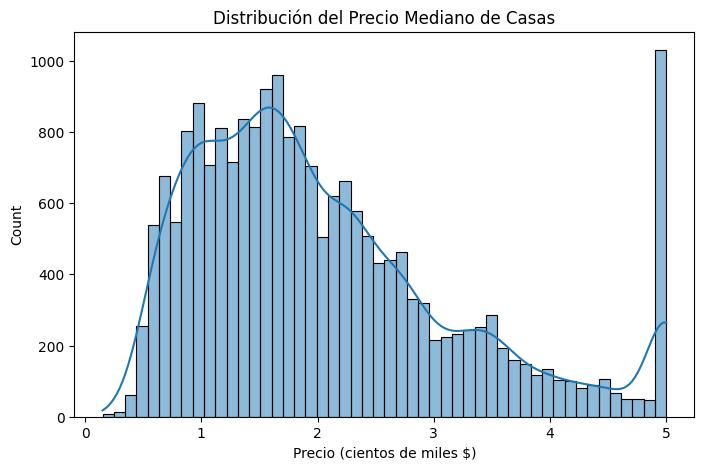

In [3]:
# Cargar dataset de California Housing desde scikit-learn
housing = fetch_california_housing()

# Convertir los datos en un DataFrame
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target  # Precio mediano de una vivienda en cientos de miles de dólares

# Mostrar la forma de las matrices de características y del target
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("\nPrimeras 5 filas:")
display(X.head())

# Estadísticas básicas descriptivas de las varibles predictorias
print("\nEstadísticas descriptivas:")
display(X.describe())

# Distribución del target
plt.figure(figsize=(8,5))
sns.histplot(y, bins=50, kde=True)
plt.title('Distribución del Precio Mediano de Casas')
plt.xlabel('Precio (cientos de miles $)')
plt.show()

### Análisis Exploratorio

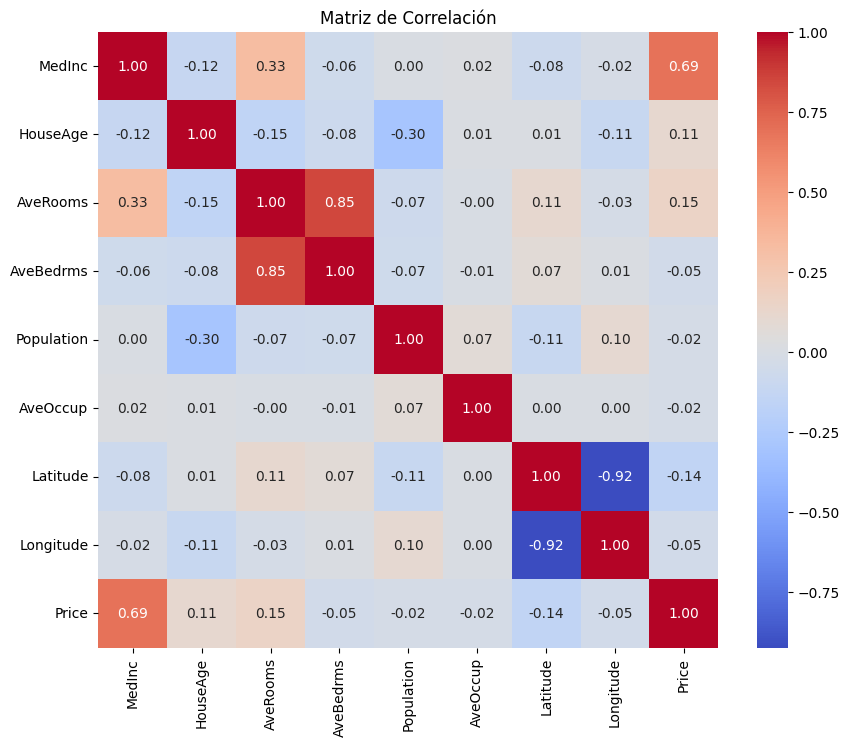

Correlaciones con el Precio:
Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64


In [4]:
# Analizar correlaciones entre todas las varibles y el precio objetivo
data = X.copy()
data['Price'] = y

# Calcular la matriz de correlación
plt.figure(figsize=(10,8))
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

# Correlaciones más fuertes con el precio
print("Correlaciones con el Precio:")
print(corr['Price'].sort_values(ascending=False))

## Preprocesamiento

In [5]:
# Paricionar el dataset en conjuntos de entrenamiento, validación y prueba
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 # 20% para test
)

# Split train/validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42 # 25% para validación
)

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

# Escalar las características para que tengan media 0 y desviación estándar 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

# Convertir a float32
X_train = X_train.astype('float32')
X_valid = X_valid.astype('float32')
X_test = X_test.astype('float32')

Train: (12384, 8), Valid: (4128, 8), Test: (4128, 8)


## Crear y Entrenar Modelo Base

In [6]:
def build_and_train_model(layers_config, optimizer, lr=0.001, batch_size=32, epochs=150, name="Modelo"):
    # Crear un modelo secuencial y definir la capa de entrada
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(X_train.shape[1],)))

    # Construir la red con capas densas, batch normalization y dropout
    for units in layers_config:
        model.add(keras.layers.Dense(units, activation='relu',
                                     kernel_regularizer=keras.regularizers.l2(0.001)))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Dropout(0.3))

    # Capa de salida para regresión con una sola unidad
    model.add(keras.layers.Dense(1))

    # Seleccionar el optimizador según el parámetro pasado
    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=lr)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=lr)

    # Compilar el modelo con pérdida de MSE y métrica de MAE
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])

    # Callback para detener el entrenamiento temprano y ajustar la tasa de aprendizaje
    callbacks = [
        keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_loss'),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, monitor='val_loss')
    ]

    # Entrenar el modelo usando los datos de entrenamiento y validación
    history = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )

    # Evaluación del modelo
    y_pred = model.predict(X_test, verbose=0).flatten()
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        'name': name,
        'layers': layers_config,
        'optimizer': optimizer,
        'lr': lr,
        'batch_size': batch_size,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'history': history,
        'model': model
    }

## Experimentos

In [7]:
resultados = []

# Experimento 1: Modelo Base - red densa intermedia con Adam
resultados.append(build_and_train_model(
    layers_config=[128, 64, 32],
    optimizer='adam',
    lr=0.001,
    batch_size=32,
    name="Baseline (Adam)"
))

# Experimento 2: Más capas + SGD
resultados.append(build_and_train_model(
    layers_config=[256, 128, 64, 32],
    optimizer='sgd',
    lr=0.01,
    batch_size=64,
    name="Deep + SGD"
))

# Experimento 3: Learning Rate más bajo
resultados.append(build_and_train_model(
    layers_config=[128, 64, 32],
    optimizer='adam',
    lr=0.0005,
    batch_size=32,
    name="Adam LR=0.0005"
))

# Experimento 4: RMSprop + batch grande
resultados.append(build_and_train_model(
    layers_config=[128, 64],
    optimizer='rmsprop',
    lr=0.001,
    batch_size=128,
    name="RMSprop + Batch 128"
))

# Convertir a DataFrame para comparación
df_resultados = pd.DataFrame([{
    'Modelo': r['name'],
    'Arquitectura': r['layers'],
    'Optimizador': r['optimizer'],
    'LR': r['lr'],
    'Batch Size': r['batch_size'],
    'RMSE': round(r['rmse'], 4),
    'MAE': round(r['mae'], 4),
    'R²': round(r['r2'], 4)
} for r in resultados])

print("Resultados:")
display(df_resultados.sort_values(by='RMSE'))

Resultados:


,Modelo,Arquitectura,Optimizador,LR,Batch Size,RMSE,MAE,R²
0,Baseline (Adam),"[128, 64, 32]",adam,0.0010,32,0.5331,0.3674,0.7831
2,Adam LR=0.0005,"[128, 64, 32]",adam,0.0005,32,0.5383,0.3720,0.7789
3,RMSprop + Batch 128,"[128, 64]",rmsprop,0.0010,128,0.5428,0.3792,0.7751
1,Deep + SGD,"[256, 128, 64, 32]",sgd,0.0100,64,0.5777,0.4014,0.7453


## Prueba con Regresión Lineal

In [8]:
# Modelo Lineal como referencia simple
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predecir con datos de prueba
y_pred_lr = lr_model.predict(X_test)

# Calcular métricas de evaluación del modelo lineal
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Regresión Lineal /:")
print(f"RMSE: {rmse_lr:.4f}")
print(f"MAE:  {mae_lr:.4f}")
print(f"R²:   {r2_lr:.4f}")

# Agregar a la tabla
df_resultados.loc[len(df_resultados)] = {
    'Modelo': 'Regresión Lineal',
    'Arquitectura': '-',
    'Optimizador': '-',
    'LR': '-',
    'Batch Size': '-',
    'RMSE': round(rmse_lr, 4),
    'MAE': round(mae_lr, 4),
    'R²': round(r2_lr, 4)
}

print("\nComparación Final (ordenado por RMSE):")
display(df_resultados.sort_values(by='RMSE'))

Regresión Lineal /:
RMSE: 0.7495
MAE:  0.5333
R²:   0.5713

Comparación Final (ordenado por RMSE):


,Modelo,Arquitectura,Optimizador,LR,Batch Size,RMSE,MAE,R²
0,Baseline (Adam),"[128, 64, 32]",adam,0.001,32,0.5331,0.3674,0.7831
2,Adam LR=0.0005,"[128, 64, 32]",adam,0.0005,32,0.5383,0.3720,0.7789
3,RMSprop + Batch 128,"[128, 64]",rmsprop,0.001,128,0.5428,0.3792,0.7751
1,Deep + SGD,"[256, 128, 64, 32]",sgd,0.01,64,0.5777,0.4014,0.7453
4,Regresión Lineal,-,-,-,-,0.7495,0.5333,0.5713


## Evaluación y Gráficos

Mejor modelo: Baseline (Adam)


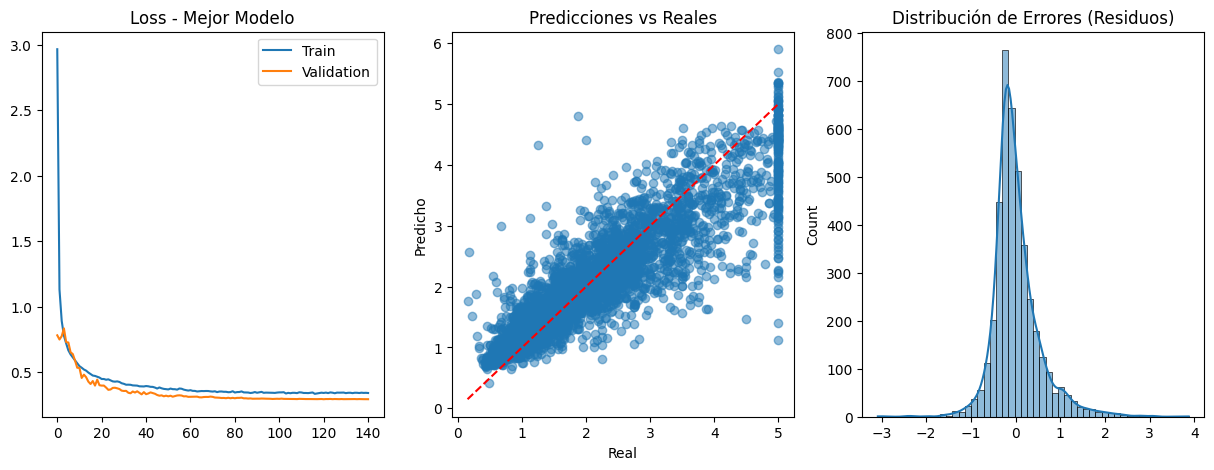

In [9]:
# Seleccionar el mejor modelo (con menor RMSE)
mejor = min(resultados, key=lambda x: x['rmse'])
print(f"Mejor modelo: {mejor['name']}")

history = mejor['history']
y_pred = mejor['model'].predict(X_test, verbose=0).flatten()

plt.figure(figsize=(15, 5))

plt.subplot(1,3,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss - Mejor Modelo')
plt.legend()

plt.subplot(1,3,2)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Predicciones vs Reales')

plt.subplot(1,3,3)
sns.histplot(y_test - y_pred, bins=50, kde=True)
plt.title('Distribución de Errores (Residuos)')
plt.show()

In [10]:
# @title
import gradio as gr
import pandas as pd

def predecir(
    MedInc, HouseAge, AveRooms, AveBedrms,
    Population, AveOccup, Latitude, Longitude
):

    datos = pd.DataFrame([[
        MedInc, HouseAge, AveRooms, AveBedrms,
        Population, AveOccup, Latitude, Longitude
    ]], columns=X.columns)

    datos = scaler.transform(datos)

    pred = mejor['model'].predict(datos, verbose=0)[0][0]

    return f"${pred*100000:,.2f} USD"


with gr.Blocks() as demo:

    gr.Markdown("# 🏠 Predicción de Precios de Viviendas")
    gr.Markdown("Modelo de Deep Learning usando California Housing Dataset")

    with gr.Row():

        with gr.Column():
            medinc = gr.Number(label="Ingreso Medio", value=3.5)
            age = gr.Number(label="Edad de la Casa", value=20)
            rooms = gr.Number(label="Habitaciones Promedio", value=5)
            beds = gr.Number(label="Dormitorios Promedio", value=1)

        with gr.Column():
            pop = gr.Number(label="Población", value=1000)
            occup = gr.Number(label="Ocupación Promedio", value=3)
            lat = gr.Number(label="Latitud", value=34)
            lon = gr.Number(label="Longitud", value=-118)

    boton = gr.Button("Predecir")
    salida = gr.Textbox(label="Precio Estimado")

    boton.click(
        predecir,
        inputs=[medinc, age, rooms, beds, pop, occup, lat, lon],
        outputs=salida
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://29bc2a1700359a76d6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
